In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

Plot distribution of m200
Save the plot data points in txt
Check what's wrong with bootstrap

In [2]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis

In [3]:
galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')


Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [4]:
import numpy as np

In [ ]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
# print(f"Number of subhalos in GG 912: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(912).getNumSubhalos()}")
rangeSat, allNumSat = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()
print(f' Range of satellites: {rangeSat}')
print(f' numer of sat == 1: {len(np.where(np.array(allNumSat) < 5)[0])}')

In [17]:
#from galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, save in a txt file
#save all galaxy groups with id, numSat, sum of flags for all satellites, mass, central mass, central flag, central r band, first satellite mass, first satellite flag, first satellite r band
with open('tng_cluster_galaxy_groups_info.txt', 'w') as f:
    f.write('id \t,numSat \t,sumFlags \t,mass \t,centralMass \t,centralFlag \t,centralRband \t,firstSatMass \t,firstSatFlag \t,firstSatRband \n')
    for i in range(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()):
        gg = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(i)
        id = gg.getGroupID()
        numSat = len(gg.getSatelliteSubhalos())
        sumFlags = np.sum([int(subhalo.getFlag()) for subhalo in gg.getSatelliteSubhalos()])
        mass = f'{gg.getMCrit200():.2e}'
        centralMass = f'{gg.getCentralSubhalo().getStellarMass():.2e}'
        centralFlag = gg.getCentralSubhalo().getFlag()
        centralRband = f'{gg.getCentralSubhalo().getDefaultRbandMagnitude():.2}'
        firstSatMass = f'{gg.getSatelliteSubhalos()[0].getStellarMass():.2e}'
        firstSatFlag = gg.getSatelliteSubhalos()[0].getFlag()
        firstSatRband = f'{gg.getSatelliteSubhalos()[0].getDefaultRbandMagnitude():.2}'
        f.write(f'{id} \t,{numSat} \t,{sumFlags} \t,{mass} \t,{centralMass} \t,{centralFlag} \t,{centralRband} \t,{firstSatMass} \t,{firstSatFlag} \t,{firstSatRband} \n')

In [ ]:
galaxyAnalysisZ0.computeAllPlots()

In [16]:
galaxyAnalysisZ0.setSnapshot(99, newsim='TNG-Cluster', luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [ ]:

galaxyAnalysisZ0.MRLDistributionPlots()

In [ ]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    if snapshot[0] > 70:
        continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    galaxyAnalysisZ0.computeAllPlots()
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()

In [6]:
galaxyAnalysisZ0TNG300 = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='SDSS')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [15]:
print(galaxyAnalysisZ0.sim)

TNG300-1


Processing snapshot 99...
Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 913 with pairs : 18000496
Processing Subhalo 14/14 in Galaxy Group ID 4254241 with total pairs 91103841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG300-1
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 7/550 in Galaxy Group ID 0 with total pairs 150975

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_tng300z0_TNG-Cluster


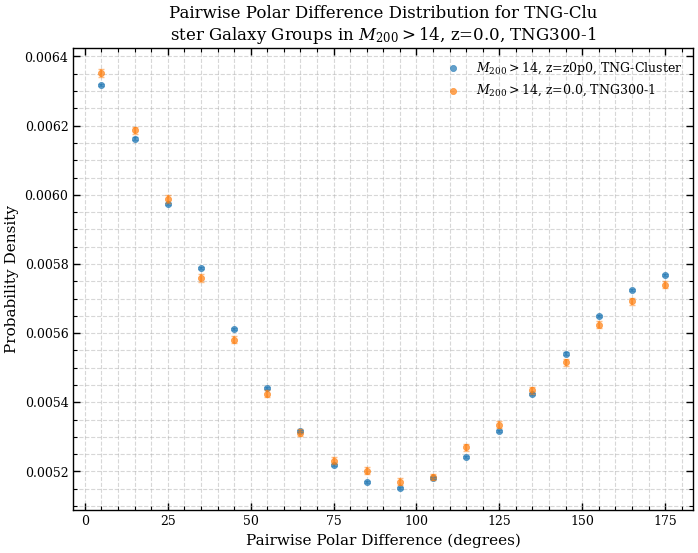

In [18]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] != 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    listRedshiftGG = []
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
    groupList.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))
    listRedshiftGG.append(groupList)

    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, mrlOrPolar='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')